$$h_\theta(\mathbf{x}) = \sigma(\boldsymbol{\theta}^\top \mathbf{x}) = \frac{1}{1 + e^{-\boldsymbol{\theta}^\top \mathbf{x}}}\\ 
\boldsymbol{\theta}^\top \mathbf{x} = \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n = \sum_{j=0}^{n} \theta_j x_j\\
J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log\left(h_\theta(x^{(i)})\right) + (1 - y^{(i)}) \log\left(1 - h_\theta(x^{(i)})\right) \right]\\
\frac{\partial J(\theta)}{\partial \theta_j} = \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}\\
\nabla_{\theta} J(\theta) = \frac{1}{m} X^T \left( h_{\theta}(X) - y \right)\\
\text{softmax}(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

原始数据形状: (891, 15)
age         177
fare          0
embarked      2
dtype: int64

📊 测试集分类报告 (Classification Report)
              precision    recall  f1-score   support

      未生存(0)       0.81      0.89      0.85       110
       生存(1)       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



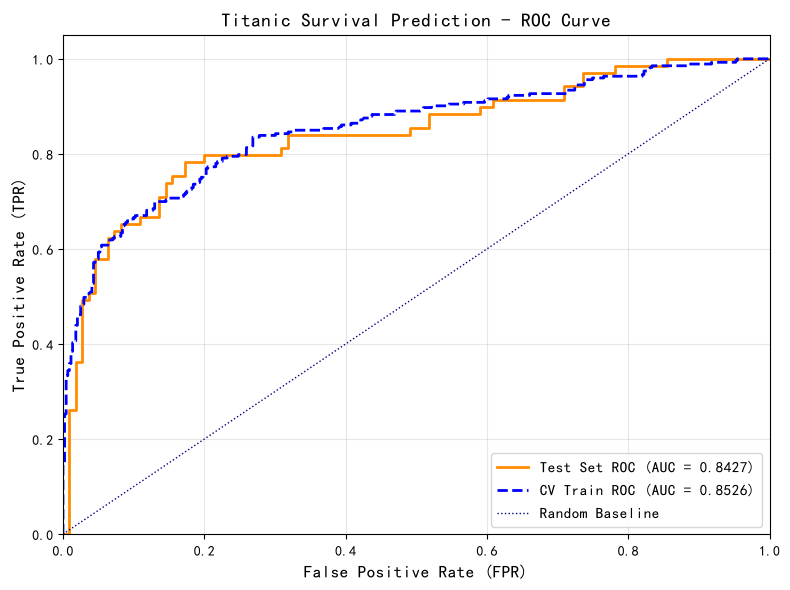


✅ Test Set AUC: 0.8427
✅ CV Train AUC: 0.8526


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc

# 设置中文显示（如果标签包含中文）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 数据加载与初步探索
# ==========================================
# 从 seaborn 或 kaggle 加载数据，这里使用 seaborn 内置数据集方便演示
try:
    import seaborn as sns
    df = sns.load_dataset('titanic')
except ImportError:
    # 如果没有seaborn，请替换为本地csv路径: pd.read_csv('train.csv')
    raise ImportError("请安装 seaborn (pip install seaborn) 或手动加载 csv 文件")

print(f"原始数据形状: {df.shape}")
print(df[['age', 'fare', 'embarked']].isnull().sum())

# 选择关键特征进行建模
# 数值型特征
num_features = ['age', 'fare', 'parch', 'sibsp']
# 类别型特征
cat_features = ['sex', 'pclass', 'embarked']

X = df[num_features + cat_features]
y = df['survived']

# ==========================================
# 2. 构建预处理与模型 Pipeline
# ==========================================
# 数值型处理：中位数填充 + 标准化
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 类别型处理：众数填充 + OneHot编码
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 组合预处理器
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

# 完整Pipeline：预处理 + 逻辑回归
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# ==========================================
# 3. 划分数据集 & 交叉验证预测
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 在训练集上拟合
model_pipeline.fit(X_train, y_train)

# 使用交叉验证获取更稳健的预测概率（用于绘制ROC）
# 注意：cross_val_predict 默认在 X_train 上做CV，避免数据泄露
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores_cv = cross_val_predict(
    model_pipeline, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]

# 在测试集上的最终预测
y_pred = model_pipeline.predict(X_test)
y_scores_test = model_pipeline.predict_proba(X_test)[:, 1]

# ==========================================
# 4. 输出分类报告
# ==========================================
print("\n" + "="*50)
print("📊 测试集分类报告 (Classification Report)")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['未生存(0)', '生存(1)']))

# ==========================================
# 5. 绘制 ROC 曲线
# ==========================================
# 计算测试集的 ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores_test)
roc_auc = auc(fpr, tpr)

# 计算交叉验证的 ROC（可选，展示模型稳定性）
fpr_cv, tpr_cv, _ = roc_curve(y_train, y_scores_cv)
roc_auc_cv = auc(fpr_cv, tpr_cv)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Test Set ROC (AUC = {roc_auc:.4f})')
plt.plot(fpr_cv, tpr_cv, color='blue', lw=2, linestyle='--',
         label=f'CV Train ROC (AUC = {roc_auc_cv:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':', label='Random Baseline')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Titanic Survival Prediction - ROC Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ Test Set AUC: {roc_auc:.4f}")
print(f"✅ CV Train AUC: {roc_auc_cv:.4f}")